# Quantum Computing Assignment: Grover's Algorithm with Teleportation

In this assignment, you will create a 12-qubit quantum circuit that implements Grover's search algorithm. The objective is to use Grover's algorithm on the first 4 qubits to search for the state `0010`. After applying the Grover oracle and diffuser once, you will use a quantum teleportation protocol to transfer the state of these 4 qubits, with the help of the next 4 qubits, to the last 4 qubits. Then, you will apply the oracle and diffuser again to the last 4 qubits to search for the same state `0010`. The final result will be simulated using a noisy environment under depolarizing noise.

You are provided with an outline of the circuit that you should build, as shown below:

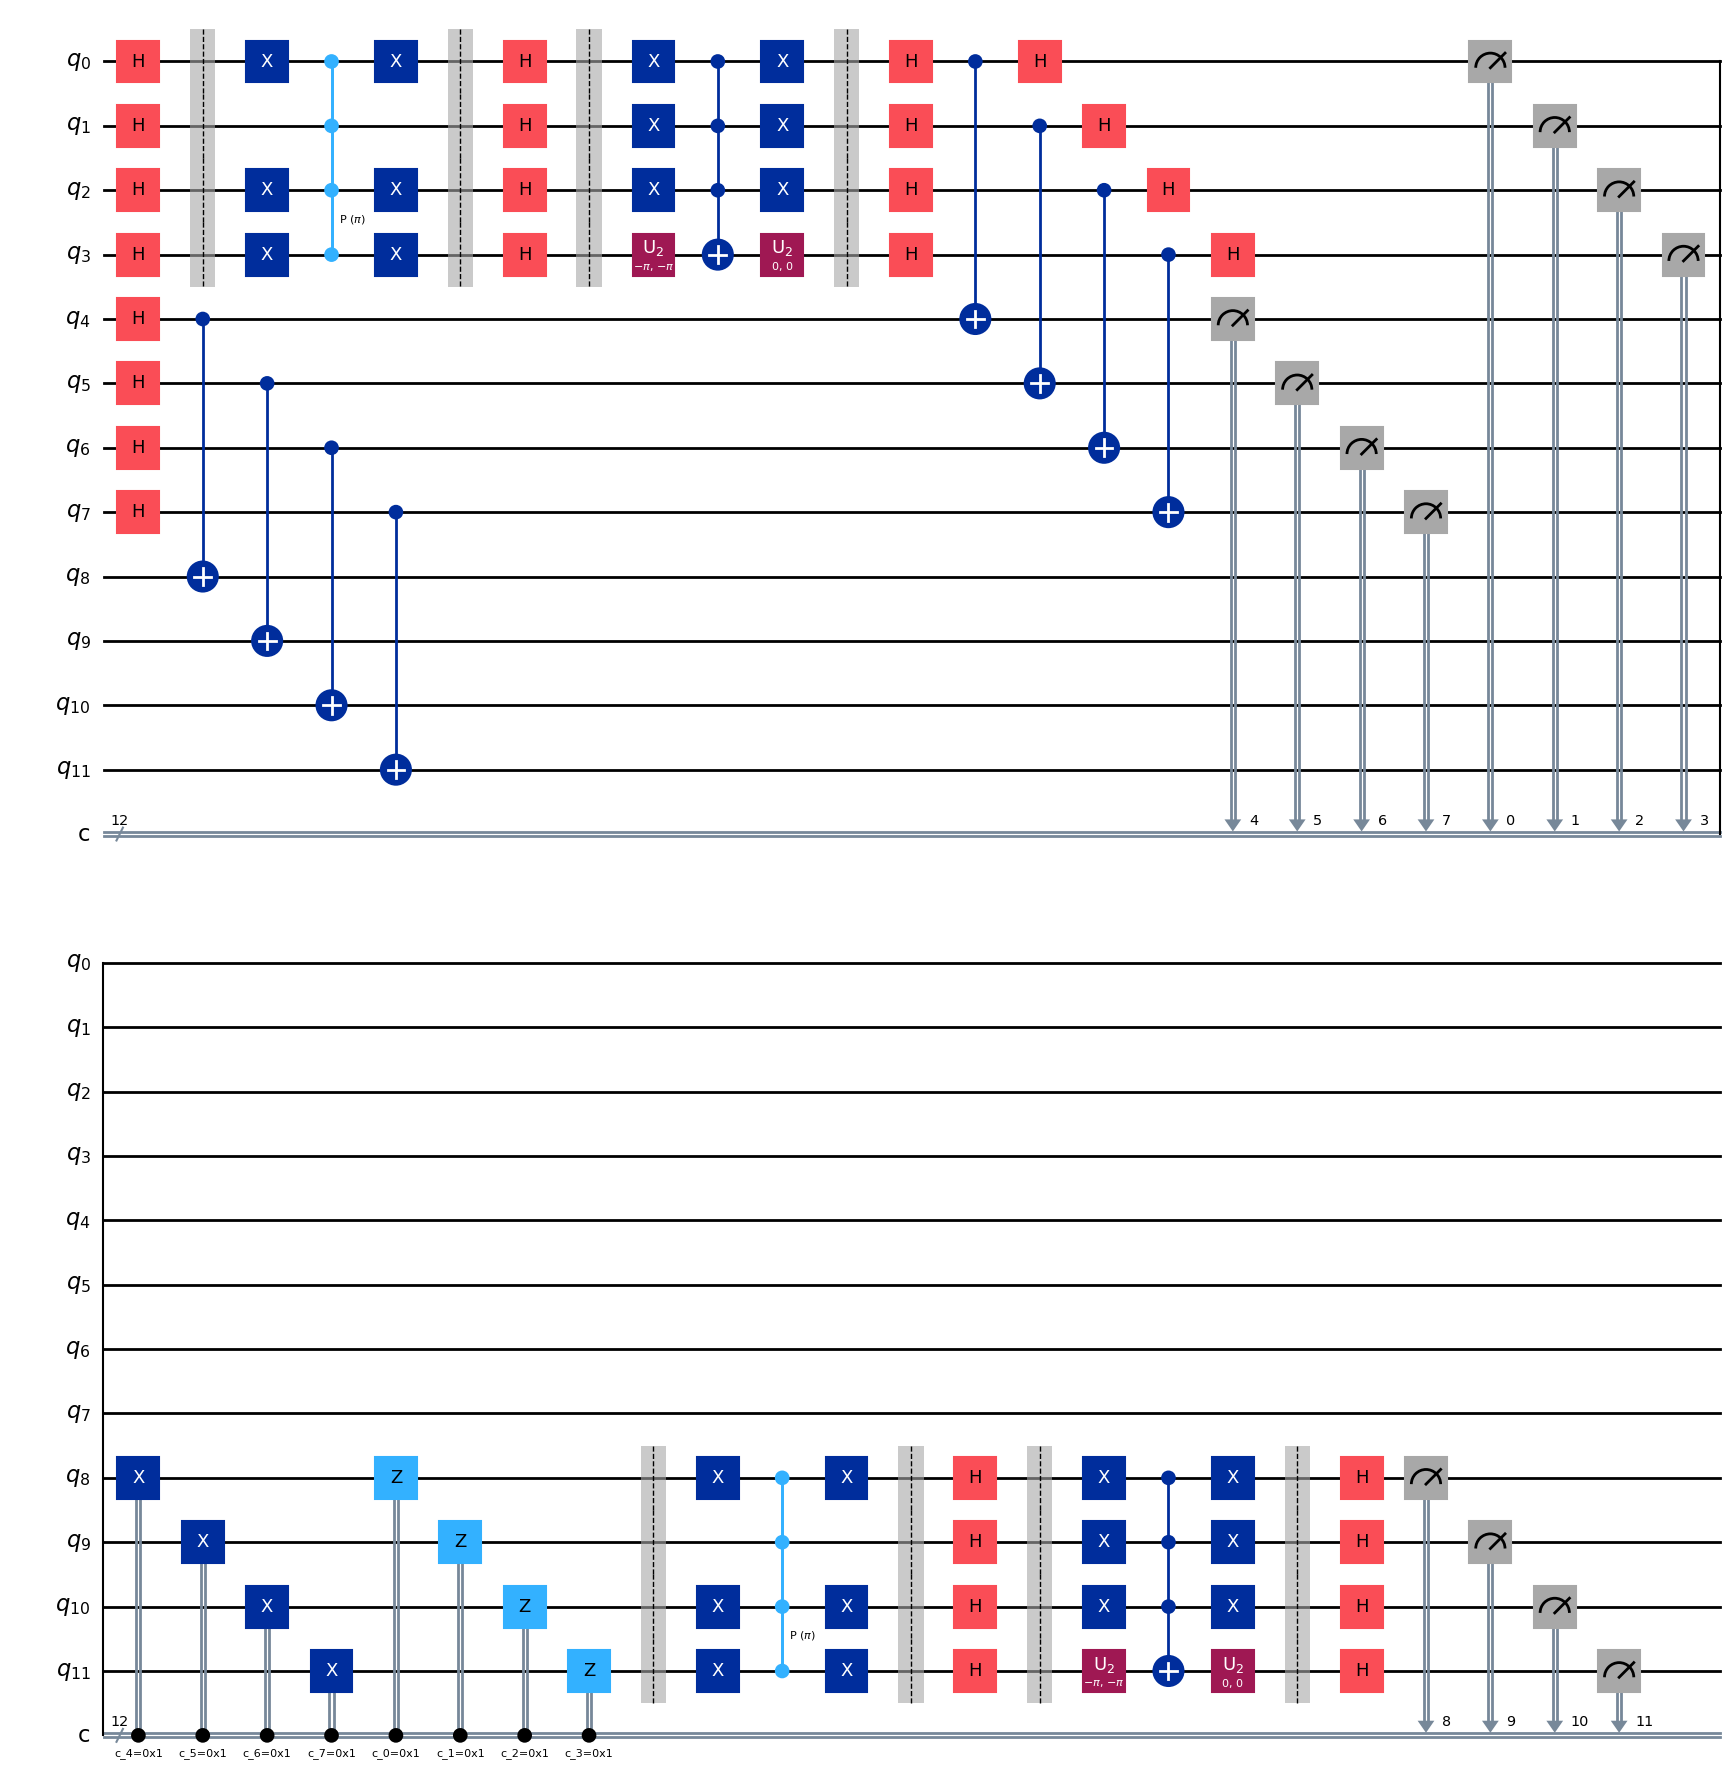

You will use the following steps to complete the task:

### Steps:

1. **Initialize a 12-qubit circuit**.
2. **Use `GroverOperator` to simplify Grover's algorithm**:
    - Import `GroverOperator` from `qiskit.circuit.library`.
    - Use the code below to define the oracle for the state `0010`
```python
mark_state = QuantumCircuit(4)
mark_state.x([0, 2, 3])
mark_state.mcp(pi, list(range(3)), 3)
mark_state.x([0, 2, 3])
```
    - Use `GroverOperator` to automatically generate a Grover operator.
    - Apply the Grover operator on the first 4 qubits once.
3. **Use the next 4 qubits as ancillae** to teleport the state of the first 4 qubits to the last 4 qubits.
    - Apply the quantum teleportation protocol between the first 4 qubits and the last 4 qubits.
4. **Apply the GroverOperator again** on the last 4 qubits to search for `0010`.
5. **Simulate the entire process** using the Aer simulator under depolarizing noise and retrieve the result of the last 4 qubits.

### Noise Model Hint

The noise model should include depolarizing noise for different types of gates with the following probabilities:

- 1-qubit gates: `0.001`
- 2-qubit gates: `0.01`
- 4-qubit gates: `0.1`

You can implement this noise model using Qiskit's noise module as shown below:

```python
# Create depolarizing errors for different gate types
error1 = noise.depolarizing_error(prob_1, 1)
error2 = noise.depolarizing_error(prob_2, 2)
error3 = noise.depolarizing_error(prob_3, 4)

# Add quantum errors according to the gates exist in the circuit
noise_model.add_all_qubit_quantum_error(error1, ['h', 'u2', 'x', 'z'])  # 1-qubit gates
noise_model.add_all_qubit_quantum_error(error2, ['cx'])  # 2-qubit gates
noise_model.add_all_qubit_quantum_error(error3, ['mcp', 'mcx'])  # 4-qubit gates
```

The outcome should be the same if you put 42 as the Aer's seed:

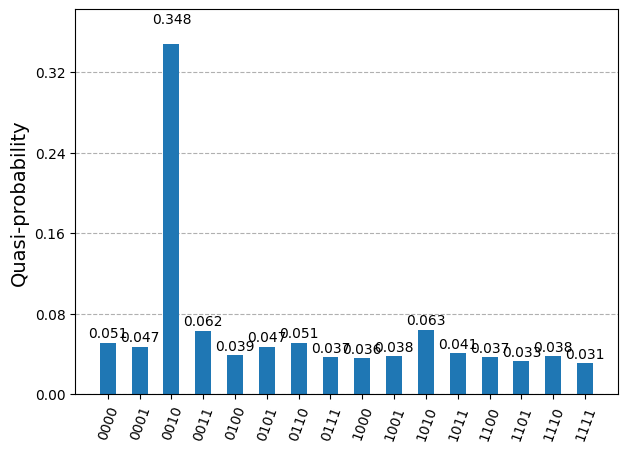

In [1]:
#Exercise3:Done by Mohammad Bolokian in 3 October2024 #
!pip install qiskit ipywidgets
!pip install pylatexenc
! pip install qiskit-aer

  Using cached jedi-0.19.1-py2.py3-none-any.whl.metadata (22 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 53.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 MB 17.1 MB/s eta 0:00:00
Using cached jedi-0.19.1-py2.py3-none-any.whl (1.6 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.5/108.5 kB 5.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=dcbd10fcfb93cb4f78f2400b1b00a93557d8aea0338f002b743b68cd8ce02cfe
  Stored in directory: /root/.cache/pip/wheels/d3/31/8b/e09b0386afd80cfc556c00408c9aeea5c35c4d484a9c762fd5
Successfully built py

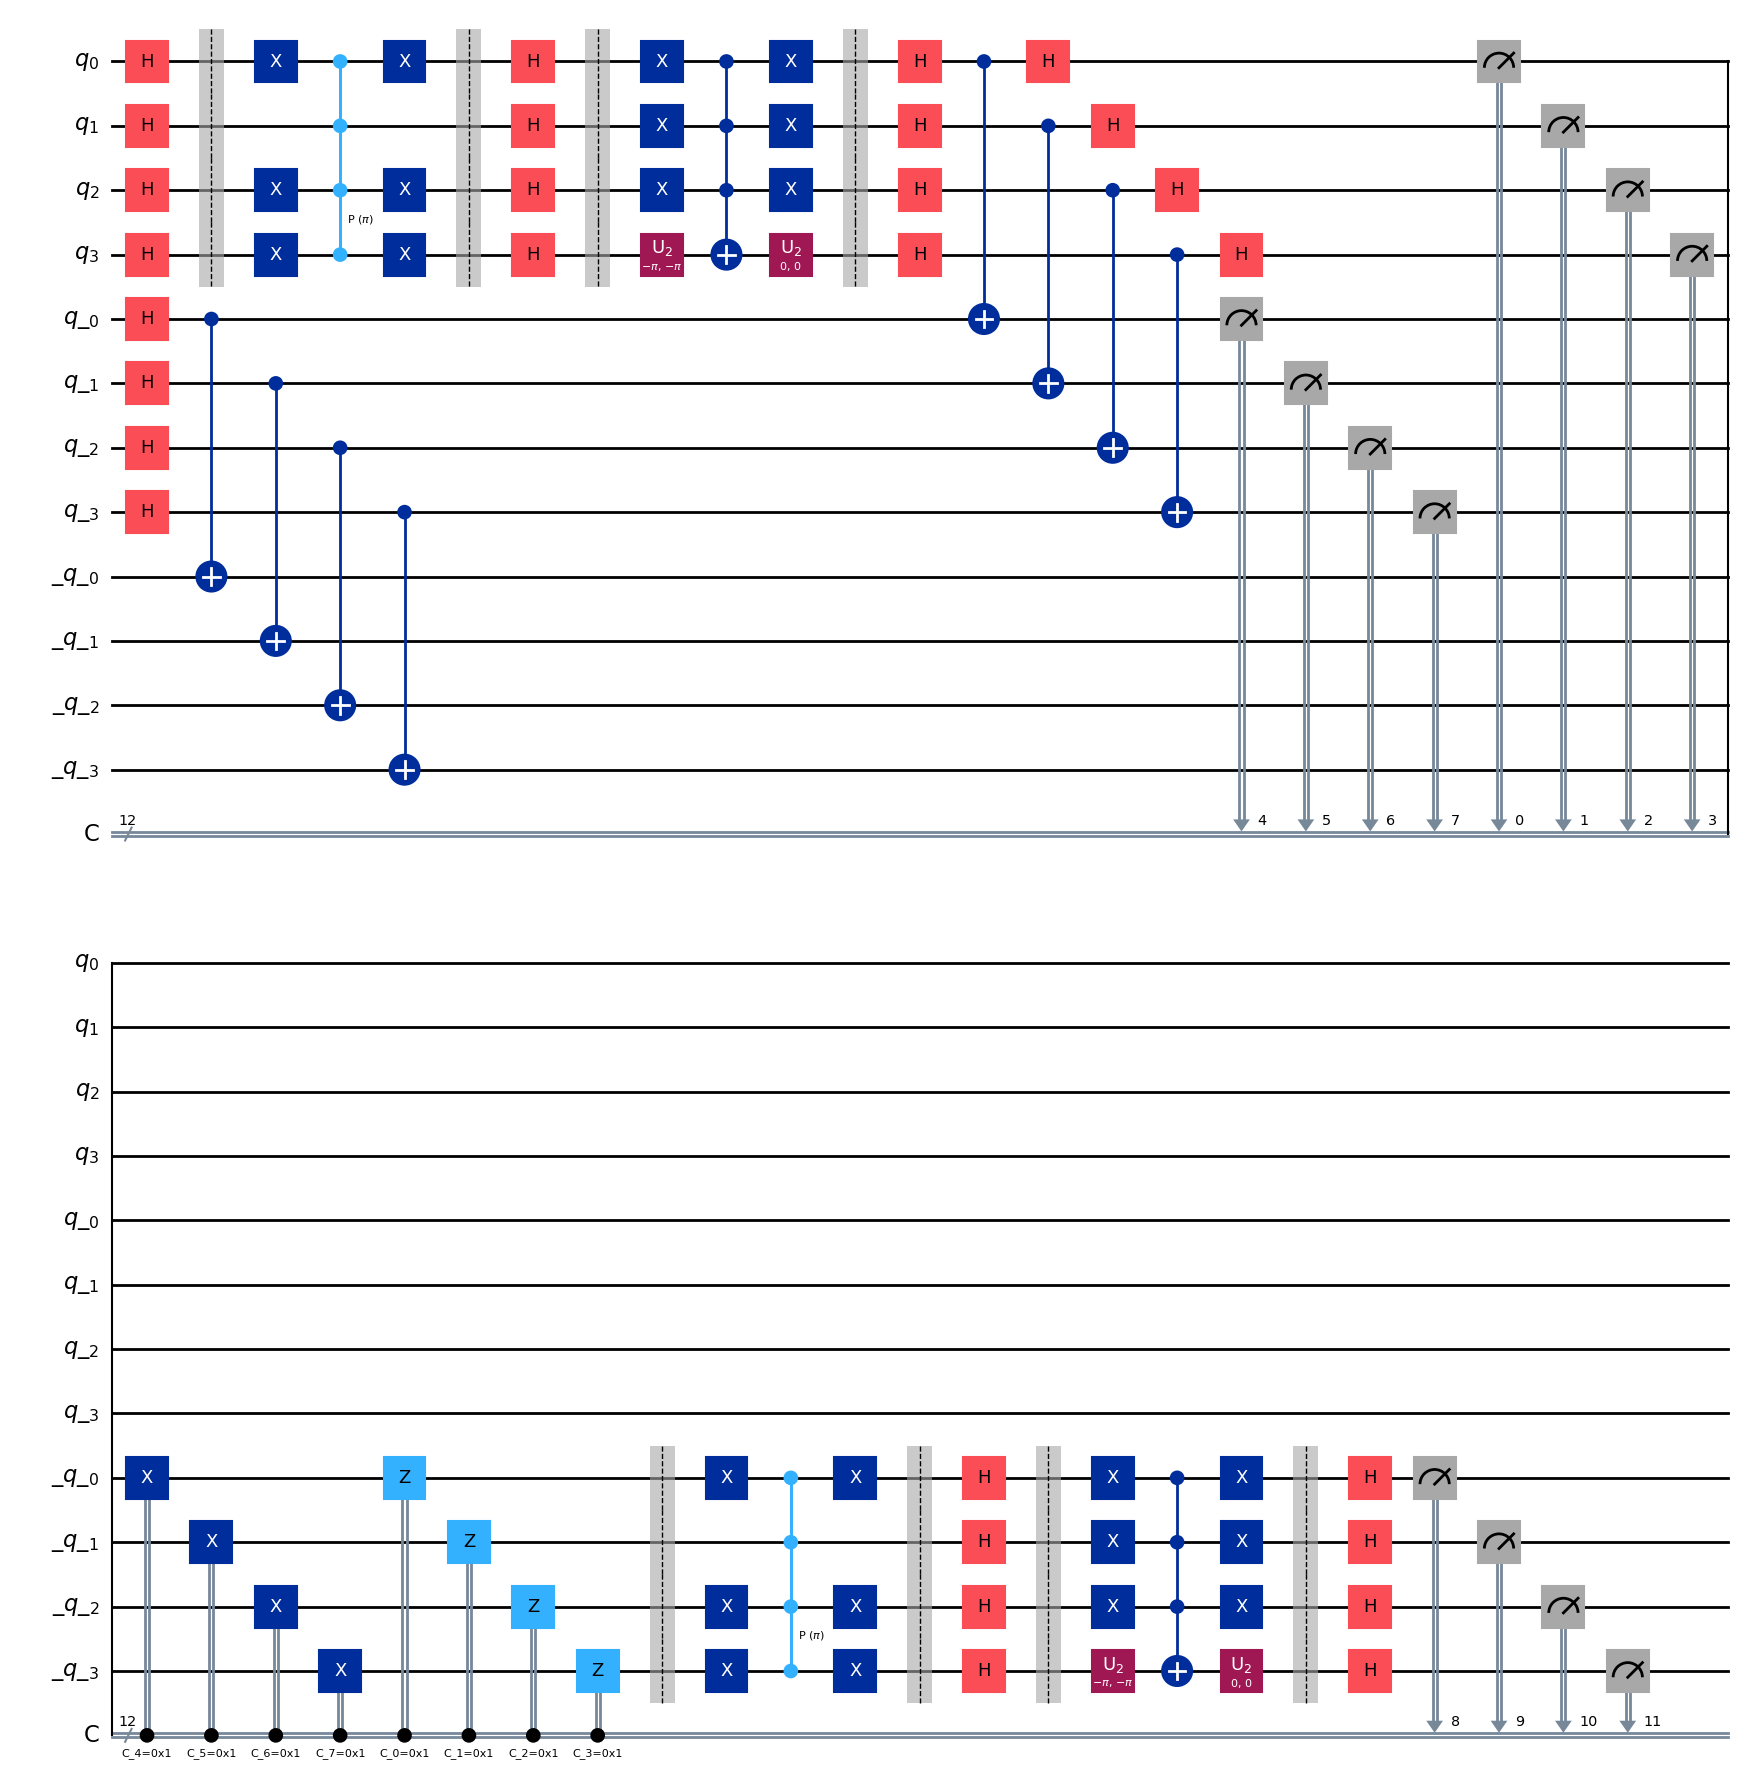

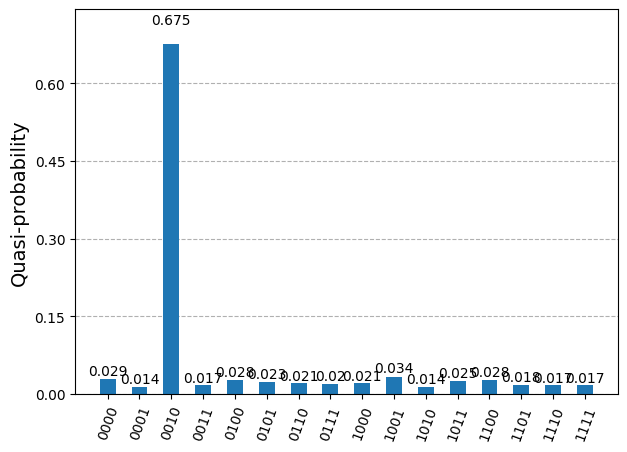

In [2]:
#Exercise3:Done by Mohammad Bolokian in 3 October2024 #

from qiskit import QuantumCircuit
from qiskit import QuantumRegister, ClassicalRegister, transpile
from qiskit.quantum_info import Statevector
from qiskit.result.utils import marginal_counts
from qiskit_aer import AerSimulator
from qiskit_aer import noise
from qiskit_aer import AerSimulator
from qiskit.circuit.library import U2Gate
from qiskit.visualization import plot_distribution
import math
pi = math.pi
Q1 = QuantumRegister(4, 'q')
Q2 = QuantumRegister(4, "q_")
Q3 = QuantumRegister(4, "_q_")
classic = ClassicalRegister(12, "C")
qc = QuantumCircuit(Q1, Q2, Q3, classic)
qc.h([0,1,2,3,4,5,6,7])
qc.barrier([0,1,2,3])
pi = math.pi

############################## Oracle #########################################

qc.x([0,2,3])
qc.mcp(pi,[0,1,2], [3])
qc.x([0,2,3])
qc.barrier([0,1,2,3])
qc.h(range(4))
qc.barrier([0,1,2,3])

############################## Diffuser #########################################

qc.x([0,1,2])
qc.append(U2Gate(-pi,-pi),[3])
qc.mcx([0,1,2],[3])
qc.x([0,1,2])
qc.append(U2Gate(0,0),[3])
qc.barrier([0,1,2,3])
qc.h(range(4))
qc.cx(4, 8)
qc.cx(5, 9)
qc.cx(6, 10)
qc.cx(7, 11)
qc.cx(0, 4)
qc.cx(1, 5)
qc.cx(2, 6)
qc.cx(3, 7)
qc.h(range(4))
qc.measure([0,1,2,3],[0,1,2,3])
qc.measure([4,5,6,7],[4,5,6,7])
qc.x(8).c_if(classic[4],1)
qc.x(9).c_if(classic[5],1)
qc.x(10).c_if(classic[6],1)
qc.x(11).c_if(classic[7],1)
qc.z(8).c_if(classic[0],1)
qc.z(9).c_if(classic[1],1)
qc.z(10).c_if(classic[2],1)
qc.z(11).c_if(classic[3],1)
qc.barrier([8,9,10,11])

############################## Oracle #########################################

qc.x([8,10,11])
qc.mcp(pi,[8,9,10], [11])
qc.x([8,10,11])
qc.barrier([8,9,10,11])
qc.h([8,9,10,11])
qc.barrier([8,9,10,11])

############################## Diffuser ########################################


qc.x([8,9,10])
qc.append(U2Gate(-pi,-pi),[11])
qc.mcx([8,9,10],[11])
qc.x([8,9,10])
qc.append(U2Gate(0,0),[11])
qc.barrier([8,9,10,11])
qc.h([8,9,10,11])
qc.measure([8,9,10,11],[8,9,10,11])
prob1 = 0.001
prob2 = 0.01
prob3 = 0.1
error1 = noise.depolarizing_error(prob1, 1)
error2 = noise.depolarizing_error(prob2, 2)
error3 = noise.depolarizing_error(prob3, 4)
noise_model = noise.NoiseModel()
basis_gates = noise_model.basis_gates
noise_model.add_all_qubit_quantum_error(error1, ['h', 'u2', 'x', 'z'])
noise_model.add_all_qubit_quantum_error(error2, ['cx'])
noise_model.add_all_qubit_quantum_error(error3, ['mcp', 'mcx'])
simulator_aer=AerSimulator(seed_simulator = 42)
qc_aer = transpile(qc, backend=simulator_aer)
result_noisy = simulator_aer.run(qc_aer,
shots=653,
noise_model=noise_model,
basis_gates=basis_gates).result()
counts_noisy = result_noisy.get_counts()
Marginal_counts = marginal_counts(counts_noisy, indices=[8,9,10,11])
display(qc_aer.draw('mpl'))
plot_distribution([Marginal_counts])